We train the sea ice classification algorithm against a manually validated set of 16x16 pixel patches. We randomly selected either the Aqua or Terra scene from each of the 179 cases. We took a uniform random sample of 100 positions across the full 500 km by 500 km (2000 by 2000 pixel) scene. Positions within the land mask are rejected. The remaining points are considered for the following categories:
* cloud-free ice: MODIS cloud < 5%, ASI sea ice concentration > 85%
* cloud-free water: MODIS cloud < 5%, ASI sea ice concentration = 0%
* cloud-ice: MODIS cloud = 100%, ASI sea ice concentration > 85%
* cloud-water: MODIS cloud = 100%, ASI sea ice concentration < 5%
Samples are derived by first generating samples, and flagging the categories based on binary masks (ASI=0, ASI> 85%, cloud<5%, cloud=>95%). These are turned to a Shapefile with property tables. Then, in QGIS, we accept or reject samples according to each category. The final input labeled sample set contains the mean band 1, band 2, and band 7 reflectance, sample centers, sample bounding boxes, and binary columns `init_cloud_free_ice`, `init_cloud_free_water`, `init_cloud_ice`, `init_cloud_water` (the initial threshold base categories), and the manually assessed `cloud_free_ice`, `cloud_free_water`, `cloud_ice`, `cloud_water`. Ambiguous samples receive a `0` in all four categories.


# to do
## scripts
- convert 500 km cloud fraction into PNG
- draw and save samples

## organization
- save MODIS images on Zenodo
- add script to download and save

In [1]:
import skimage.io as io
import os
import pandas as pd
import numpy as np
import ultraplot as uplt

dataloc = "../../calval_tgrs/data/validation_dataset/modis_500km/"
plot_examples = True
recompute = False

key = io.imread("../data/metadata/color_key.png")
vals = pd.DataFrame(np.mean(key[:, :, :-1], axis=0), columns=['r', 'g', 'b']).round(0).astype(int)
bin_mean_values = vals.iloc[6::14,:].astype(int)[['r', 'g', 'b']]

n = len(bin_mean_values)
bin_edges = np.linspace(0, 100, n+1)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_mean_values.index = bin_centers

files = os.listdir(dataloc + 'cloudfraction')
files = [f for f in files if '.tiff' in f]
files.sort()

# Example:
file = files[31]
cn, region, dx, suffix = file.split('-')
date, satellite, imtype, res, ftype = suffix.split('.')
case = cn + '_' + satellite
rgb_img = io.imread(dataloc + file).astype(float)
n, m, c = rgb_img.shape
gray_img = np.zeros((n, m))
red = rgb_img[:, :, 0].astype(float)
green = rgb_img[:, :, 1].astype(float)
blue = rgb_img[:, :, 2].astype(float)
cloud_free = (green < 1) & (np.abs(red - 102) < 1) & (np.abs(blue - 119) < 1)
cloud_covered = (green < 6) & (red > 250) &  np.abs(blue < 30)

fc_img = io.imread((dataloc + file).replace('cloudfraction', 'falsecolor'))
land_img = io.imread((dataloc + file).replace('cloudfraction', 'landmask'))


FileNotFoundError: [Errno 2] No such file or directory: '/Users/dwatkin2/Documents/research/manuscripts/calval_tgrs/data/validation_dataset/modis_500km/016-baffin_bay-500km-20070605.terra.cloudfraction.250m.tiff'

In [24]:
fc_img = io.imread((dataloc + file).replace('cloudfraction', 'falsecolor'))
# not all scenes have this!
sic_img = io.imread(dataloc.replace('modis_500km', 'asi_500km').replace('cloudfraction', 'sea_ice_concentration') + \
                    file.replace('cloudfraction', 'sea_ice_concentration').replace(
                        'terra', 'asi').replace(
                        'aqua', 'asi').replace(
                        '250m.tiff', '6250m.png'))

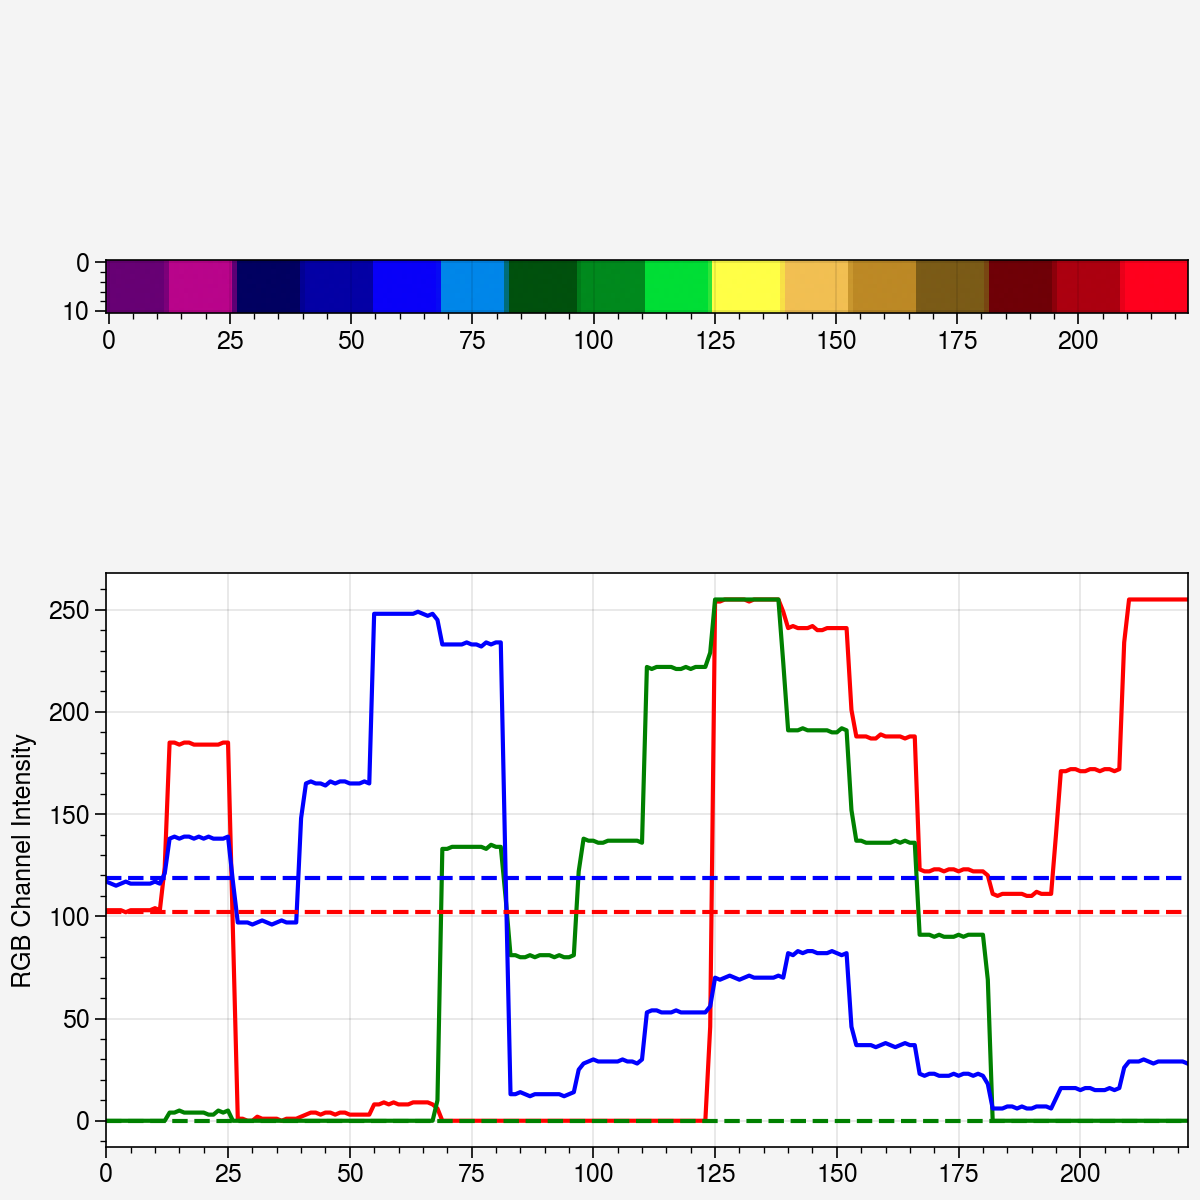

In [25]:
fig, ax = uplt.subplots(nrows=2, share=False, height=6, width=6)
ax[0].imshow(key)
ax[1].plot(key[5, :, 0], color='r')
ax[1].plot(key[5, :, 1], color='g')
ax[1].plot(key[5, :, 2], color='b')

ax[1].axhline(102, color='r', ls='--')
ax[1].axhline(0, color='g', ls='--')
ax[1].axhline(119, color='b', ls='--')
ax[1].format(ylabel="RGB Channel Intensity")

In [26]:
red = rgb_img[:, :, 0].astype(float)
green = rgb_img[:, :, 1].astype(float)
blue = rgb_img[:, :, 2].astype(float)
cloud_free = (green < 1) & (np.abs(red - 102) < 1) & (np.abs(blue - 119) < 1)
cloud_covered = (green < 6) & (red > 250) &  np.abs(blue < 30)

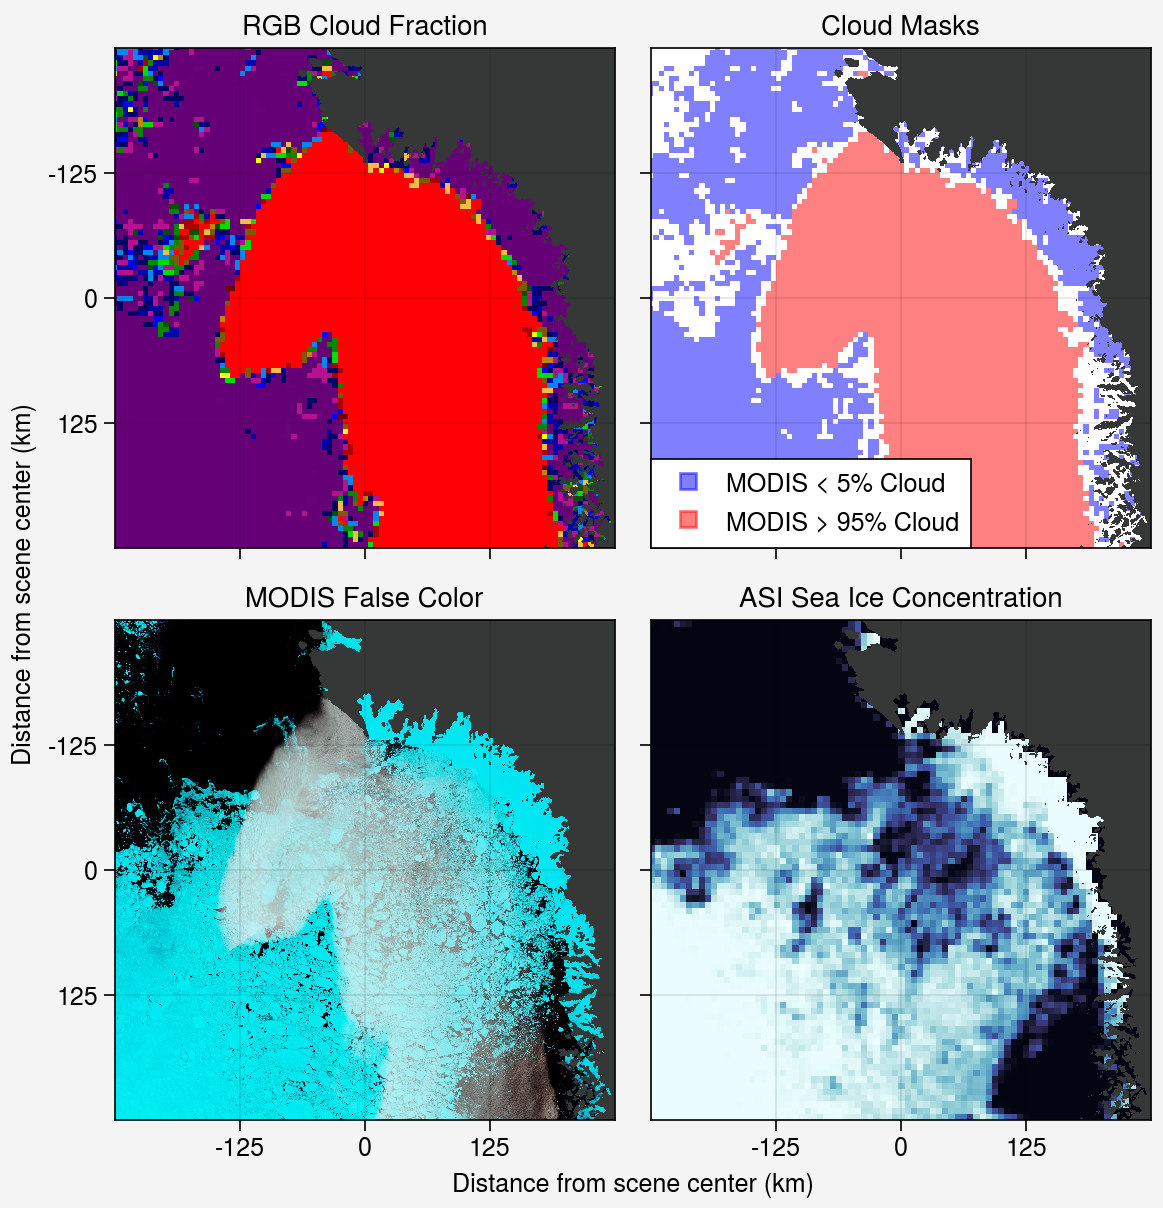

In [41]:
fig, axs = uplt.subplots(ncols=2, nrows=2)
axs[0].imshow(rgb_img.astype(int))
axs[1].imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
axs[1].imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
axs[2].imshow(fc_img)
axs[3].imshow(sic_img / 255 * 100, cmap='ice', vmin=0, vmax=100)
ticks = np.arange(500, 2000, 500)
ticklabels = [str(round((y-1000)*0.25)) for y in np.arange(500, 2000, 500)]
for ax in axs:
    ax.imshow(np.ma.masked_array(land_img, land_img==0), color='dark gray')
    ax.format(xlocator=ticks, ylocator=ticks,
              xtickminor=False, ytickminor=False, 
              xformatter=ticklabels, yformatter=ticklabels,
              ylabel='Distance from scene center (km)', 
              xlabel='Distance from scene center (km)'
             )

h = [ax.plot([],[], m='s', color=c, lw=0, alpha=0.5) for c in ['b', 'r']]
axs[1].legend(h, ['MODIS < 5% Cloud', 'MODIS > 95% Cloud'], alpha=1, ncols=1, loc='ll')
axs[0].format(title='RGB Cloud Fraction')
axs[1].format(title='Cloud Masks')
axs[2].format(title='MODIS False Color')
axs[3].format(title="ASI Sea Ice Concentration")

Selecting the extremes is faster than the pixel-to-percentage mapping. Since we are initializing a map of points to then verify

2d uniform random sample

array(['001', '002', '003', '004', '005', '006', '007', '008', '009',
       '010', '011', '012', '013', '014', '015', '016', '017', '018',
       '019', '020', '021', '022', '023', '024', '025', '026', '027',
       '028', '029', '030', '031', '032', '033', '034', '035', '036',
       '037', '038', '039', '040', '041', '042', '043', '044', '045',
       '046', '047', '048', '049', '050', '051', '052', '053', '054',
       '055', '056', '057', '058', '059', '060', '061', '062', '063',
       '064', '065', '066', '067', '068', '069', '070', '071', '072',
       '073', '074', '075', '076', '077', '078', '079', '080', '081',
       '082', '083', '084', '085', '086', '087', '088', '089', '090',
       '091', '092', '093', '094', '095', '096', '097', '098', '099',
       '100', '101', '102', '103', '104', '105', '106', '107', '108',
       '109', '110', '111', '112', '113', '114', '115', '116', '117',
       '118', '119', '120', '121', '122', '123', '124', '125', '126',
       '127', '128',

We draw a random sample of locations within each index with the constraint that points are separated by at least 10 km, which is two pixels in the cloud mask product.



In [22]:
import scipy
import skimage
from skimage.measure import regionprops_table
import skimage.morphology as skim


# oversample and reduce to correct distance, then take first keep_n samples
n = 2000
imsize=2000
keep_n = 500

g = np.random.default_rng(seed=2340)
sampled_points = {}
for case in case_numbers:
    points = g.choice(range(8, imsize-8), (2, n)) 
    keep = np.ones(n)
    jcomp = np.arange(0, n)
    min_dx = 50
    d = pd.DataFrame(scipy.spatial.distance.cdist(points.T, points.T),
                     columns=jcomp, index=jcomp)
    for idx in range(0, n):
        if keep[idx] > 0:
            di = d.loc[idx, jcomp != idx]
            keep[di[di <= min_dx].index] = 0
    sampled_points[case] = points[:, keep > 0][:, 0:keep_n]

# Turning points to samples
- Expand using 16x16 template
- Somehow there are still points not being saved, or overlapping, which is dumb
- So, 

In [50]:
sample_patches = sampled_points[case]

Z = np.zeros((2000, 2000))
for idx in range(0, len(sample_points.T)):
    Z[sample_points[0, idx], sample_points[1, idx]] = 1
sample_patches = skim.dilation(Z, skim.footprint_rectangle((16,16)))
sample_patches = skimage.morphology.label(sample_patches)

df = pd.DataFrame(
    regionprops_table(
        sample_patches,
        fc_img,
        properties=["area", "label", "bbox", "centroid", "intensity_mean"])
    ).set_index('label')

df.rename({
    'bbox-0': 'min_row',
    'bbox-1': 'min_col',
    'bbox-2': 'max_row',
    'bbox-3': 'max_col',
    'centroid-0': 'row_centroid',
    'centroid-1': 'col_centroid',
    'intensity_mean-0': 'band_7_mean_reflectance',
    'intensity_mean-1': 'band_2_mean_reflectance',
    'intensity_mean-2': 'band_1_mean_reflectance',
}, inplace=True, axis=1
)

for mask_img, varname = zip(
    [cloud_free, cloud_covered, land, sic_asi, land_asi, sic_nsidc, land_nsidc],
    ['cloud_free_fraction', 'cloud_covered_fraction', 'land_modis_fraction',
     'sic_asi_fraction', 'land_asi_fraction',
    'sic_nsidc_fraction', 'land_nsidc_fraction']
    ):
     props = regionprops_table(
        sample_patches, 
        intensity_image=mask_img,
        properties=["label", "intensity_mean"])
    df[varname] = pd.Series(props['intensity_mean'], index=props['label'])
land_tol = 0.1
idx = (df_all.land_modis_fraction < land_tol) & (df_all.land_nsidc_fraction < land_tol) & (df_all.land_asi_fraction < land_tol)
df_all = df_all.loc[idx, :].copy()

cloud_tol = 0.9 # Fraction that needs to be covered by mask to "count"
low_ice_tol = 0.01 # Maximum SIC to classify as water
high_ice_tol = 0.85 # Minimum SIC to classify as ice

# Default to using ASI ice fraction
df_all.loc[:, "init_cloud_free_water"] = (df_all["sic_asi_fraction"] < low_ice_tol) & (df_all["cloud_free_fraction"] > cloud_tol)
df_all.loc[:, "init_cloud_free_ice"] = (df_all["sic_asi_fraction"] > high_ice_tol) & (df_all["cloud_free_fraction"] > cloud_tol)
df_all.loc[:, "init_cloudy_water"] = (df_all["sic_asi_fraction"] < low_ice_tol) & (df_all["cloud_covered_fraction"] > cloud_tol)
df_all.loc[:, "init_cloudy_ice"] = (df_all["sic_asi_fraction"] > high_ice_tol) & (df_all["cloud_covered_fraction"] > cloud_tol)

# Use NSIDC where the ASI data is missing
idx = df_all.sic_asi_fraction < 0
df_all.loc[idx, "init_cloud_free_water"] = (df_all.loc[idx, "sic_nsidc_fraction"] < low_ice_tol) & (df_all.loc[idx, "cloud_free_fraction"] > cloud_tol)
df_all.loc[idx, "init_cloud_free_ice"] = (df_all.loc[idx, "ndisc_sic_fraction"] > high_ice_tol) & (df_all.loc[idx, "cloud_free_fraction"] > cloud_tol)
df_all.loc[idx, "init_cloudy_water"] = (df_all.loc[idx, "sic_nsidc_fraction"] < low_ice_tol) & (df_all.loc[idx, "cloud_covered_fraction"] > cloud_tol)
df_all.loc[idx, "init_cloudy_ice"] = (df_all.loc[idx, "sic_nsidc_fraction"] > high_ice_tol) & (df_all.loc[idx, "cloud_covered_fraction"] > cloud_tol)


'016-baffin_bay-500km-20070605.terra.cloudfraction.250m.tiff'

TBD:
1. Subset the dataframe to just the ones with no land in the patch and with at least one "true" category
2. Also clear the regions within the ASI land mask -- don't assign those values to 0
3. Use the bounding box to define a geometry
   - Add geopandas to the imports list
   - Add shapely to the imports list
   - Import box from shapely.geometry
   - Get the coordinates from the geotiff transform
   - Subset the data table to where there is at least one positive initial category
   - Add a geometry column to the data table
5. Use geopandas to export the result to file
6. Loop through all cases and generate tables for each
7. Use QGIS to evaluate the bounding boxes and tag boxes which should be rejected or re-categorized, ideally in bulk
8. Analysis: How often are there 100% MODIS clouds which get rejected by an observer?
9. Analysis: How often are there 0% ASI SIC which contain obvious ice?

In [8]:
import skimage.io as io
import os
import pandas as pd
import numpy as np
import ultraplot as uplt
import scipy
import skimage
from skimage.measure import regionprops_table
import skimage.morphology as skim
import geopandas as gpd
from shapely.geometry import box
import rasterio as rio

dataloc = "../../calval_tgrs/data/validation_dataset/modis_500km/"
asi_dataloc = "../../calval_tgrs/data/validation_dataset/asi_500km/"
nsidc_dataloc = "../../calval_tgrs/data/validation_dataset/nsidc_500km/"
sample_saveloc = '/Users/dwatkin2/Documents/research/manuscripts/calval_tgrs/data/validation_dataset/calibration_500km/'

files = os.listdir(dataloc + 'cloudfraction')
files = [f for f in files if '.tiff' in f]
files.sort()

In [9]:
case_numbers = np.unique([f.split('-')[0] for f in files])

# oversample and reduce to correct distance, then take first keep_n samples
n = 2000
imsize=2000
keep_n = 500

g = np.random.default_rng(seed=2340)
sampled_points = {}
for case in case_numbers:
    points = g.choice(range(8, imsize-8), (2, n)) 
    keep = np.ones(n)
    jcomp = np.arange(0, n)
    min_dx = 50
    d = pd.DataFrame(scipy.spatial.distance.cdist(points.T, points.T),
                     columns=jcomp, index=jcomp)
    for idx in range(0, n):
        if keep[idx] > 0:
            di = d.loc[idx, jcomp != idx]
            keep[di[di <= min_dx].index] = 0
    sampled_points[case] = points[:, keep > 0][:, 0:keep_n]

for file in files:
    cn, region, dx, suffix = file.split('-')
    date, satellite, imtype, res, ftype = suffix.split('.')
    
    # Load cloud masks
    rgb_img = io.imread(dataloc + 'cloudfraction/' + file).astype(float)
    red = rgb_img[:, :, 0].astype(float)
    green = rgb_img[:, :, 1].astype(float)
    blue = rgb_img[:, :, 2].astype(float)
    cloud_free = (green < 1) & (np.abs(red - 102) < 1) & (np.abs(blue - 119) < 1)
    cloud_covered = (green < 6) & (red > 250) &  np.abs(blue < 30)

    # Load false color image and land mask
    fc_img = io.imread((dataloc + 'falsecolor/' + file).replace('cloudfraction', 'falsecolor'))
    land_modis = io.imread((dataloc + 'landmask/' + file).replace('cloudfraction', 'landmask')) > 0

    # Load sea ice concentration masks. 
    prefix = file.split('.')[0]
    sic_nsidc = io.imread(nsidc_dataloc + 'sea_ice_concentration/' + prefix + '.nsidc.sea_ice_concentration.25km.png').astype(float) / 255
    land_nsidc = io.imread(nsidc_dataloc + 'landmask/' + prefix + '.nsidc.landmask.25km.png').astype(float) / 255

    # If year = 2012, sic_asi may be missing -- set to -1 in that case
    try:
        sic_asi = io.imread(asi_dataloc + 'sea_ice_concentration/' + prefix + '.asi.sea_ice_concentration.6250m.png').astype(float) / 255
        land_asi = io.imread(asi_dataloc + 'landmask/' + prefix + '.asi.landmask.6250m.png').astype(float) / 255
    except:
        sic_asi = -1 * np.ones(sic_nsidc.shape) # Sets it all to -1 so that when we take the mean, we can filter easily
        land_asi = sic_asi.copy()

    # Load samples corresponding to the current case
    sample_points = sampled_points[cn]

    # Expand points to patches
    Z = np.zeros((2000, 2000))
    for idx in range(0, len(sample_points.T)):
        Z[sample_points[0, idx], sample_points[1, idx]] = 1
    sample_patches = skim.dilation(Z, skim.footprint_rectangle((16,16)))
    sample_patches = skimage.morphology.label(sample_patches)
    
    df = pd.DataFrame(
        regionprops_table(
            sample_patches,
            fc_img[:, :, :3], # drop the alpha channel
            properties=["area", "label", "bbox", "centroid", "intensity_mean"])
        ).set_index('label')
    
    df.rename({
        'bbox-0': 'min_row',
        'bbox-1': 'min_col',
        'bbox-2': 'max_row',
        'bbox-3': 'max_col',
        'centroid-0': 'row_center',
        'centroid-1': 'col_center',
        'intensity_mean-0': 'b7_mean',
        'intensity_mean-1': 'b2_mean',
        'intensity_mean-2': 'b1_mean',
    }, inplace=True, axis=1
    )
    
    for mask_img, varname in zip(
        [cloud_free, cloud_covered, land_modis, sic_asi, land_asi, sic_nsidc, land_nsidc],
        ['clear', 'cloud', 'land_modis',
         'sic_asi', 'land_asi',
        'sic_nsidc', 'land_nsidc']
        ):
        props = regionprops_table(
            sample_patches, 
            intensity_image=mask_img,
            properties=["label", "intensity_mean"]
        )
        df[varname] = pd.Series(props['intensity_mean'], index=props['label'])

    land_tol = 0.1
    idx = (df.land_modis < land_tol) & (df.land_nsidc < land_tol) & (df.land_asi < land_tol)
    df = df.loc[idx, :].copy()
    
    cloud_tol = 0.9 # Fraction that needs to be covered by mask to "count"
    low_ice_tol = 0.01 # Maximum SIC to classify as water
    high_ice_tol = 0.85 # Minimum SIC to classify as ice
    
    # Default to using ASI ice fraction
    df.loc[:, "clr_water"] = (df["sic_asi"] < low_ice_tol) & (df["clear"] > cloud_tol)
    df.loc[:, "clr_ice"] = (df["sic_asi"] > high_ice_tol) & (df["clear"] > cloud_tol)
    df.loc[:, "cld_water"] = (df["sic_asi"] < low_ice_tol) & (df["cloud"] > cloud_tol)
    df.loc[:, "cld_ice"] = (df["sic_asi"] > high_ice_tol) & (df["cloud"] > cloud_tol)
    
    # Use NSIDC where the ASI data is missing
    idx = df.sic_asi < 0
    df.loc[idx, "clr_water"] = (df.loc[idx, "sic_nsidc"] < low_ice_tol) & (df.loc[idx, "clear"] > cloud_tol)
    df.loc[idx, "clr_ice"] = (df.loc[idx, "sic_nsidc"] > high_ice_tol) & (df.loc[idx, "clear"] > cloud_tol)
    df.loc[idx, "cld_water"] = (df.loc[idx, "sic_nsidc"] < low_ice_tol) & (df.loc[idx, "cloud"] > cloud_tol)
    df.loc[idx, "cld_ice"] = (df.loc[idx, "sic_nsidc"] > high_ice_tol) & (df.loc[idx, "cloud"] > cloud_tol)

    df['init_cat'] = 'none'
    df.loc[df.clr_water, 'init_cat'] = 'clear_water'
    df.loc[df.clr_ice, 'init_cat'] = 'clear_ice'
    df.loc[df.cld_water, 'init_cat'] = 'cloudy_water'
    df.loc[df.cld_ice, 'init_cat'] = 'cloudy_ice'

    # Copied column -- category for samples after manual check
    df['manual_cat'] = df['init_cat']
    
    ref_img = rio.open((dataloc + 'falsecolor/' + file).replace('cloudfraction', 'falsecolor'))
    
    # Since the image coordinates are reversed, the largest row number will be the lowest y value.
    x_min, y_min = ref_img.xy(row=df['max_row'], col=df['min_col'])
    x_max, y_max = ref_img.xy(row=df['min_row'], col=df['max_col'])
    df['left_x'] = x_min
    df['right_x'] = x_max
    df['top_y'] = y_max
    df['bottom_y'] = y_min
    
    df['geometry'] = [box(x_min, y_min, x_max, y_max) for x_min, y_min, x_max, y_max in 
                  zip(df.left_x, df.bottom_y, df.right_x, df.top_y)]
    folder = file.replace('.cloudfraction.250m.tiff', '').replace('.', '-') + '-samples'
    os.makedirs(sample_saveloc + folder, exist_ok=True)
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs=ref_img.crs)
    gdf.to_file(sample_saveloc + folder + '/' + file.replace('cloudfraction.250m.tiff', 'samples.shp'))
        
    del fc_img, rgb_img, sic_nsidc, land_nsidc, sic_asi, land_asi, cloud_free, cloud_covered, df, gdf
    ref_img.close()

In [16]:
pd.DataFrame(
        regionprops_table(
            sample_patches,
            fc_img[:, :, :3], # drop the alpha channel
            properties=["area", "label", "bbox", "centroid", "intensity_mean"])
        ).set_index('label').columns

Index(['area', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'centroid-0',
       'centroid-1', 'intensity_mean-0', 'intensity_mean-1',
       'intensity_mean-2'],
      dtype='object')

In [20]:
df

,area,min_row,min_col,max_row,max_col,row_center,col_center,b7_mean,b2_mean,clear,...,land_nsidc,clear_water,clear_ice,cloud_water,cloud_ice,clr_water,clr_ice,cld_water,cld_ice,init_cat
label,,,,,,,,,,,,,,,,,,,,,
7,256.0,26,175,42,191,33.5,182.5,128.191406,201.949219,0.0,...,0.0,False,False,False,True,NaN,NaN,NaN,NaN,none
27,256.0,119,173,135,189,126.5,180.5,53.703125,85.578125,0.0,...,0.0,False,False,False,False,NaN,NaN,NaN,NaN,none
36,256.0,149,32,165,48,156.5,39.5,141.039062,191.582031,0.0,...,0.0,False,False,False,True,NaN,NaN,NaN,NaN,none
40,256.0,171,180,187,196,178.5,187.5,20.148438,39.308594,0.0,...,0.0,False,False,False,False,NaN,NaN,NaN,NaN,none
48,256.0,200,98,216,114,207.5,105.5,54.613281,118.644531,0.0,...,0.0,False,False,False,False,NaN,NaN,NaN,NaN,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,256.0,1943,1307,1959,1323,1950.5,1314.5,160.062500,207.878906,0.0,...,0.0,False,False,True,False,NaN,NaN,NaN,NaN,none
495,256.0,1963,1030,1979,1046,1970.5,1037.5,159.566406,215.796875,0.0,...,0.0,False,False,True,False,NaN,NaN,NaN,NaN,none
497,256.0,1965,928,1981,944,1972.5,935.5,76.894531,199.925781,0.0,...,0.0,False,False,True,False,NaN,NaN,NaN,NaN,none


In [4]:
# Plotting
save_loc = '/Users/dwatkin2/Documents/research/manuscripts/calval_tgrs/figures/calibration_sample_quicklooks/'
for file in files[150:-1]:
    cn, region, dx, suffix = file.split('-')
    date, satellite, imtype, res, ftype = suffix.split('.')
    
    # Load cloud masks
    rgb_img = io.imread(dataloc + 'cloudfraction/' + file).astype(float)
    red = rgb_img[:, :, 0].astype(float)
    green = rgb_img[:, :, 1].astype(float)
    blue = rgb_img[:, :, 2].astype(float)
    cloud_free = (green < 1) & (np.abs(red - 102) < 1) & (np.abs(blue - 119) < 1)
    cloud_covered = (green < 6) & (red > 250) &  np.abs(blue < 30)

    # Load false color image and land mask
    fc_img = io.imread((dataloc + 'falsecolor/' + file).replace('cloudfraction', 'falsecolor'))
    land_modis = io.imread((dataloc + 'landmask/' + file).replace('cloudfraction', 'landmask')) > 0

    # Load sea ice concentration masks. 
    prefix = file.split('.')[0]
    sic_nsidc = io.imread(nsidc_dataloc + 'sea_ice_concentration/' + prefix + '.nsidc.sea_ice_concentration.25km.png').astype(float) / 255
    land_nsidc = io.imread(nsidc_dataloc + 'landmask/' + prefix + '.nsidc.landmask.25km.png').astype(float) / 255

    # If year = 2012, sic_asi may be missing -- set to -1 in that case
    try:
        sic_asi = io.imread(asi_dataloc + 'sea_ice_concentration/' + prefix + '.asi.sea_ice_concentration.6250m.png').astype(float) / 255
        land_asi = io.imread(asi_dataloc + 'landmask/' + prefix + '.asi.landmask.6250m.png').astype(float) / 255
    except:
        sic_asi = -1 * np.ones(sic_nsidc.shape) # Sets it all to -1 so that when we take the mean, we can filter easily
        land_asi = sic_asi.copy()

    folder = file.replace('.cloudfraction.250m.tiff', '').replace('.', '-') + '-samples'
    df = gpd.read_file(sample_saveloc + folder + '/' + file.replace('cloudfraction.250m.tiff', 'samples.shp'))
    
    fig, axs = uplt.subplots(ncols=4)

    axs[1].imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
    axs[1].imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
    axs[2].imshow(sic_asi, cmap='ice', vmin=0, vmax=1)
    axs[3].imshow(sic_nsidc, cmap='ice', vmin=0, vmax=1)
    axs[0].imshow(fc_img)
    
    category_colors = {
        'clear_water': 'blue6',
        'cloudy_water': 'red2',
        'clear_ice': 'blue1',
        'cloudy_ice': 'red7'
    }
    
    category_labels = {
        'clear_water': 'Clear-Sky Water',
        'cloudy_water': 'Cloud-Covered Water',
        'clear_ice': 'Clear-Sky Ice',
        'cloudy_ice': 'Cloud-Covered Ice',
        'none': 'NA'
    }
    
    
    for ax in axs:
        for name, data in df.groupby('init_cat'):
            m='o'
            if name == 'none':
                facecolor='none'
                m='^'
            else:
                facecolor = category_colors[name]
                
            ax.scatter(
                data.col_center, data.row_center, edgecolor='k',
                marker=m, facecolor=facecolor, label=category_labels[name]
            )
    axs[1].legend(ncols=2, loc='b')
    
    for ax in axs:
        ax.imshow(np.ma.masked_array(land_modis, land_modis==0), color='gray', alpha=1)
    
    for ax, title in zip(axs, ['False Color', 'Cloud Masks', 'ASI Sea Ice Concentration', 'NSIDC Sea Ice Concentration']):
        ax.format(title=title)
    
    case_number, region, size, suffix = file.split('-')
    date, satellite, imtype, scale, ftype = suffix.split('.')
    fig.format(
        suptitle='Case {cn}: {rn}, {d} ({s})'.format(cn=case_number, rn=region.replace('_', ' ').title(),
                                                    d=pd.to_datetime(date).strftime('%Y-%m-%d'), s=satellite.title())
    )
    
    ticks = np.arange(500, 2000, 500)
    ticklabels = [str(round((y-1000)*0.25)) for y in np.arange(500, 2000, 500)]
    for ax in axs:
        ax.format(xlocator=ticks, ylocator=ticks,
                  xtickminor=False, ytickminor=False, 
                  xformatter=ticklabels, yformatter=ticklabels,
                  ylabel='Distance from scene center (km)', 
                  xlabel='Distance from scene center (km)'
                 )
    fig.save(save_loc + cn + '_' + satellite + '_initial_sample_categories.png', dpi=300)
    uplt.close(fig)

    del fc_img, rgb_img, sic_nsidc, land_nsidc, sic_asi, land_asi, cloud_free, cloud_covered, df, gdf

NameError: name 'gdf' is not defined

In [7]:
df = gpd.read_file(sample_saveloc + folder + '/' + file.replace('cloudfraction.250m.tiff', 'samples.shp'))
df.columns

Index(['label', 'area', 'min_row', 'min_col', 'max_row', 'max_col',
       'row_center', 'col_center', 'b7_mean', 'b2_mean', 'clear', 'cloud',
       'land_modis', 'sic_asi', 'land_asi', 'sic_nsidc', 'land_nsidc',
       'clr_water', 'clr_ice', 'cld_water', 'cld_ice', 'init_cat',
       'manual_cat', 'left_x', 'right_x', 'top_y', 'bottom_y', 'geometry'],
      dtype='object')

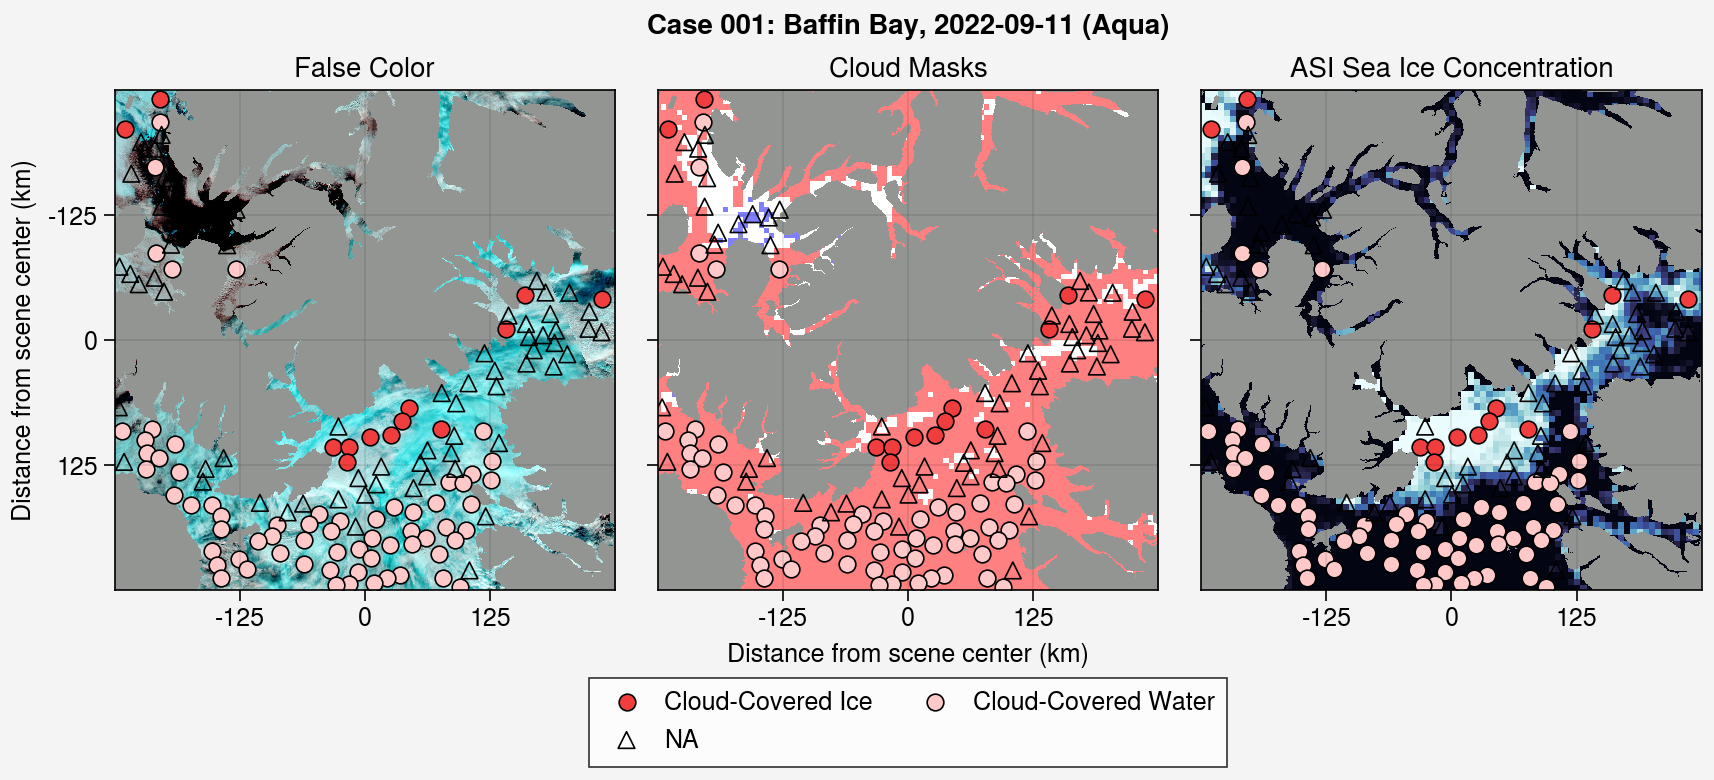

In [36]:
fig, axs = uplt.subplots(ncols=3)

axs[1].imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
axs[1].imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
axs[2].imshow(sic_asi, cmap='ice', vmin=0, vmax=1)
axs[0].imshow(fc_img)

category_colors = {
    'clear_water': 'blue6',
    'cloudy_water': 'red2',
    'clear_ice': 'blue1',
    'cloudy_ice': 'red7'
}

category_labels = {
    'clear_water': 'Clear-Sky Water',
    'cloudy_water': 'Cloud-Covered Water',
    'clear_ice': 'Clear-Sky Ice',
    'cloudy_ice': 'Cloud-Covered Ice',
    'none': 'NA'
}


for ax in axs:
    for name, data in df.groupby('init_cat'):
        m='o'
        if name == 'none':
            facecolor='none'
            m='^'
        else:
            facecolor = category_colors[name]
            
        ax.scatter(
            data.col_center, data.row_center, edgecolor='k',
            marker=m, facecolor=facecolor, label=category_labels[name]
        )
axs[1].legend(ncols=2, loc='b')

for ax in axs:
    ax.imshow(np.ma.masked_array(land_modis, land_modis==0), color='gray', alpha=1)

for ax, title in zip(axs, ['False Color', 'Cloud Masks', 'ASI Sea Ice Concentration']):
    ax.format(title=title)

case_number, region, size, suffix = file.split('-')
date, satellite, imtype, scale, ftype = suffix.split('.')
fig.format(
    suptitle='Case {cn}: {rn}, {d} ({s})'.format(cn=case_number, rn=region.replace('_', ' ').title(),
                                                d=pd.to_datetime(date).strftime('%Y-%m-%d'), s=satellite.title())
)

ticks = np.arange(500, 2000, 500)
ticklabels = [str(round((y-1000)*0.25)) for y in np.arange(500, 2000, 500)]
for ax in axs:
    ax.format(xlocator=ticks, ylocator=ticks,
              xtickminor=False, ytickminor=False, 
              xformatter=ticklabels, yformatter=ticklabels,
              ylabel='Distance from scene center (km)', 
              xlabel='Distance from scene center (km)'
             )
fig.save('../figures/sample_example_' + cn + '_' + satellite + '.png', dpi=300)

# Compile the set of test points with initial categories


In [2]:
import geopandas as gpd
import os
import pandas as pd

In [43]:
dataloc = '/Users/dwatkin2/Documents/research/manuscripts/calval_tgrs/data/validation_dataset/calibration_500km'
folders = os.listdir(dataloc)
folders = [f for f in folders if f not in ['.DS_Store', 'calibration_table.csv']
folders.sort()

columns = ['case_number', 'region', 'date', 'satellite', 'label', 'min_row', 'min_col', 'max_row', 'max_col',
           'row_center', 'col_center', 'b7_mean', 'b2_mean', 'clear', 'cloud',
           'land_modis', 'sic_asi', 'land_asi', 'sic_nsidc', 'land_nsidc',
           'clr_water', 'clr_ice', 'cld_water', 'cld_ice', 'init_cat',
           'manual_cat', 'left_x', 'right_x', 'top_y', 'bottom_y',]

all_dfs = []
for folder in folders:
    file = next(f for f in os.listdir(os.path.join(dataloc, folder)) if '.shp' in f)
    cn, region, size, date, satellite, _ = folder.split('-')
    df_ = gpd.read_file(os.path.join(dataloc, folder, file))
    df_['case_number'] = cn
    df_['region'] = region
    df_['date'] = date
    df_['satellite'] = satellite
    all_dfs.append(df_.loc[:, columns].copy())
    del df_

In [44]:
len(all_dfs)

378

In [22]:
folder

'189-sea_of_okhostk-500km-20120426-terra-samples'

In [45]:

df = pd.concat(all_dfs)

In [46]:
df.groupby('init_cat').count()

,case_number,region,date,satellite,label,min_row,min_col,max_row,max_col,row_center,...,land_nsidc,clr_water,clr_ice,cld_water,cld_ice,manual_cat,left_x,right_x,top_y,bottom_y
init_cat,,,,,,,,,,,,,,,,,,,,,
clear_ice,10862,10862,10862,10862,10862,10862,10862,10862,10862,10862,...,10862,10862,10862,10862,10862,10862,10862,10862,10862,10862
clear_water,4377,4377,4377,4377,4377,4377,4377,4377,4377,4377,...,4377,4377,4377,4377,4377,4377,4377,4377,4377,4377
cloudy_ice,39386,39386,39386,39386,39386,39386,39386,39386,39386,39386,...,39386,39386,39386,39386,39386,39386,39386,39386,39386,39386
cloudy_water,34426,34426,34426,34426,34426,34426,34426,34426,34426,34426,...,34426,34426,34426,34426,34426,34426,34426,34426,34426,34426
none,58591,58591,58591,58591,58591,58591,58591,58591,58591,58591,...,58591,58591,58591,58591,58591,58591,58591,58591,58591,58591


In [49]:
df.to_csv('/Users/dwatkin2/Documents/research/manuscripts/calval_tgrs/data/validation_dataset/calibration_500km/calibration_table.csv')

/var/folders/_1/dv6d0pjn20bgy9ysl0pfsbr40000gn/T/ipykernel_22167/4184243430.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(sample_saveloc + file.replace('cloudfraction.250m.tiff', 'samples.shp'))
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'row_centroid' to 'row_centro'
  ogr_write(
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'col_centroid' to 'col_centro'
  ogr_write(
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'band_7_mean_reflectance' to 'band_7_mea'
  ogr_write(
/opt/miniconda3/envs/calval/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'band_2_mean_reflectance' to 'band_2_mea'
  ogr_write(
/opt/miniconda3/envs/calval/l

<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

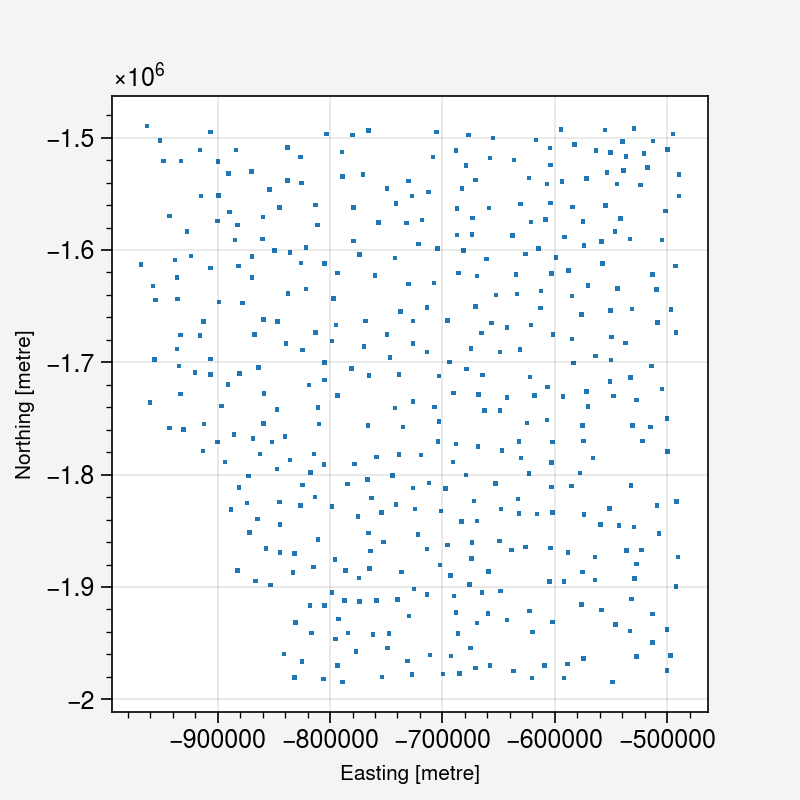

In [48]:
ref_img.bounds

BoundingBox(left=-987229.0, bottom=-1987476.0, right=-487229.0, top=-1487476.0)

In [62]:
# Top right:
r, c = ref_img.xy(row=df.min_row.values[0], col=0)
c, r
# QGIS: -1487870,-490577 (looks like this is col, row)

(np.float64(-1487851.0), np.float64(-987104.0))

In [55]:
# Top left: 
# 
r, c = ref_img.xy(row=0, col=0)
# QGIS: -1485760,-985502
c, r

(np.float64(-1487601.0), np.float64(-987104.0))

In [56]:
# Bottom right:
r, c = ref_img.xy(row=1999, col=1999)
c, r
# QGIS: -1984906,-486356

(np.float64(-1987351.0), np.float64(-487354.0))

In [57]:
# Bottom left: 
r, c = ref_img.xy(row=1999, col=0)
c, r
# -1985961,-984447

(np.float64(-1987351.0), np.float64(-987104.0))

In [59]:
r, c = ref_img.xy(row=df.row_centroid.values[0], col=df.col_centroid.values[0])
c, r

(np.float64(-1489726.0), np.float64(-963229.0))

In [50]:
x_min[0], x_max[0]

(np.float64(-965104.0), np.float64(-961104.0))

In [24]:
ref_img.index(x=x_min[0], y=y_max[0])

(17, 88)

<a list of 1 Line2D objects>

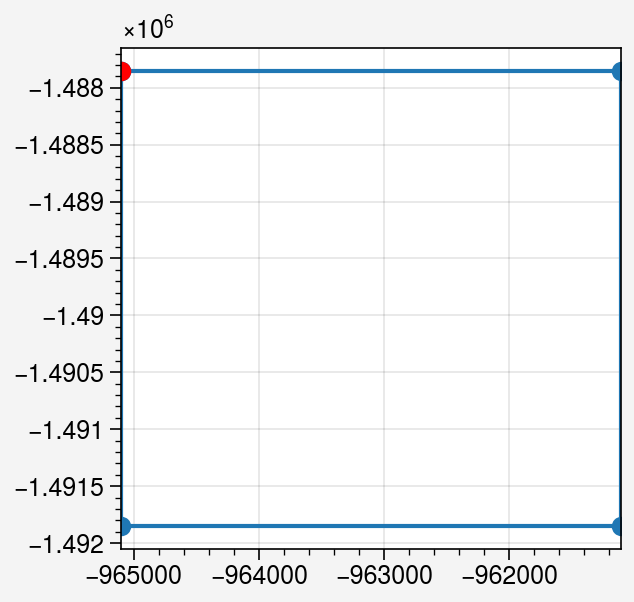

In [51]:
fig, ax = uplt.subplots()
ax.plot(
    [x_min[0], x_min[0], x_max[0], x_max[0], x_min[0]], [y_min[0], y_max[0], y_max[0], y_min[0], y_min[0]], 
marker='o')
ax.plot(x_min[0], y_min[0], color='r', marker='o')


# Adding the 100 km region bounding box

In [3]:
import geopandas as gpd
import pandas as pd
import os 

dataloc = "../../calval_tgrs/data/validation_dataset/modis_500km/"
asi_dataloc = "../../calval_tgrs/data/validation_dataset/asi_500km/"
nsidc_dataloc = "../../calval_tgrs/data/validation_dataset/nsidc_500km/"
sample_saveloc = '/Users/dwatkin2/Documents/research/manuscripts/calval_tgrs/data/validation_dataset/calibration_500km/'

files = os.listdir(dataloc + 'cloudfraction')
files = [f for f in files if '.tiff' in f]
files.sort()


file = files[0]
folder = file.replace('.cloudfraction.250m.tiff', '').replace('.', '-') + '-samples'

# df = gpd.read_file(sample_saveloc + folder + '/' + file.replace('cloudfraction.250m.tiff', 'samples.shp'))
# df.columns

# Adding the floe labels from the binary labeling method

In [5]:
df = gpd.read_file("/Users/dmw/Downloads/beaufort_sea_063.250m.2007-07-11.aqua.gpkg")

In [6]:
df

,floe_label,floe_area,floe_convex_area,floe_major_axis_length,floe_minor_axis_length,floe_orientation,floe_perimeter,floe_latitude,floe_longitude,floe_x,floe_y,geometry
0,1,310.8750,315.8125,24.405718,17.279143,-0.487917,74.617009,74.568604,-132.550042,-71875.0,-1679875.0,"POLYGON ((-1687500 -62500, -1687500 -84000, -1..."
1,2,157.6250,162.0000,16.013167,14.117619,0.905003,54.893660,74.541380,-131.702951,-96875.0,-1681625.0,"POLYGON ((-1687500 -87500, -1687500 -104000, -..."
2,3,10.9375,11.3750,4.457386,3.352604,1.185197,13.278175,74.495489,-130.888711,-121125.0,-1685125.0,"POLYGON ((-1685750 -119000, -1685750 -119250, ..."
3,4,7.3125,7.3750,4.243372,2.296794,-0.154838,10.681981,74.468613,-130.250767,-140125.0,-1686625.0,"POLYGON ((-1687000 -138250, -1687000 -138500, ..."
4,5,13.9375,13.9375,10.784046,1.711721,-0.001914,21.173097,74.416517,-128.385022,-195625.0,-1686875.0,"POLYGON ((-1687500 -190500, -1687500 -200500, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
396,397,62.1250,68.6875,11.598281,7.304163,0.458227,37.625893,76.439815,-123.105592,-304125.0,-1443875.0,"POLYGON ((-1444250 -298250, -1444250 -298500, ..."
397,398,7.0000,7.0000,3.669029,2.443665,-0.037136,9.742641,76.449425,-123.791041,-286625.0,-1446375.0,"POLYGON ((-1446750 -284750, -1446750 -285000, ..."
398,399,17.6875,17.9375,6.050150,3.786277,-1.566783,16.389087,76.458171,-122.820716,-310875.0,-1440375.0,"POLYGON ((-1441500 -309000, -1441500 -309250, ..."
399,400,30.0625,30.8750,11.877598,3.471015,0.084513,27.044417,76.629957,-126.545433,-213875.0,-1438875.0,"POLYGON ((-1439250 -209000, -1439250 -209250, ..."
